# Notebook 05 – Demand Forecasting (Time Series)
This notebook builds the second required system: predicting daily appointment volume.

## 1. Imports

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from math import sqrt

# Simple ML regressor for comparison
from sklearn.ensemble import RandomForestRegressor


## 2. Load Data

In [41]:
df = pd.read_csv("Medical_appointment_data.csv")
df.head()

,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,...,storm_day_before,rain_intensity,heat_intensity,appointment_date_continuous,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received
0,psychotherapy,17,F,yes,intellectual,Lake Marvinville,afternoon,9.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
1,NaN,7,M,no,intellectual,ITAPEMA,morning,11.0,1,0,...,1,no_rain,cold,2020-01-01,0,0,0,0,0,0
2,speech therapy,16,M,no,intellectual,ITAJAÍ,afternoon,8.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
3,speech therapy,14,M,yes,intellectual,Sarahside,afternoon,9.0,1,0,...,1,moderate,mild,2020-01-01,0,0,0,0,0,1
4,physiotherapy,8,M,no,motor,ITAJAÍ,morning,NaN,0,0,...,1,no_rain,mild,2020-01-01,0,0,0,0,0,0


## 3. Aggregate to Daily Demand

In [42]:
# Convert date
df['appointment_date_continuous'] = pd.to_datetime(df['appointment_date_continuous'])

# Daily count = demand
daily = df.groupby('appointment_date_continuous').size().reset_index(name='demand')

daily = daily.sort_values('appointment_date_continuous')
daily.head()


,appointment_date_continuous,demand
0,2020-01-01,25
1,2020-01-02,33
2,2020-01-03,18
3,2020-01-04,16
4,2020-01-05,15


## 4. Basic Visualization

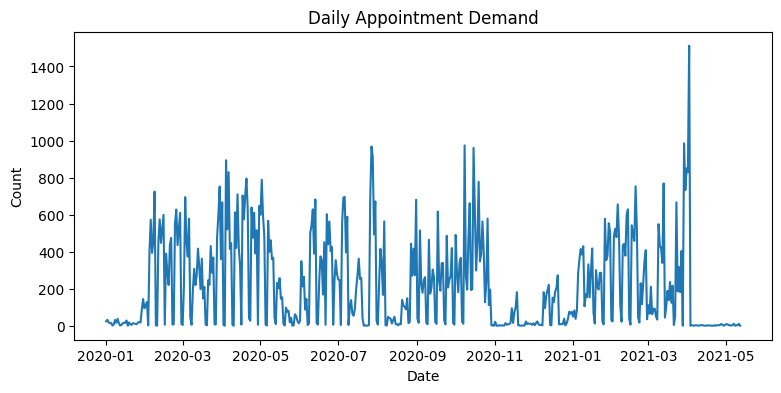

In [43]:

plt.figure(figsize=(9,4))
plt.plot(daily['appointment_date_continuous'], daily['demand'])
plt.title("Daily Appointment Demand")
plt.xlabel("Date")
plt.ylabel("Count")
plt.show()


Demand is highly irregular with structural drops and spikes, indicating influence of external factors beyond calendar effects.

## 5. Create Time Features

In [44]:

daily['weekday'] = daily['appointment_date_continuous'].dt.dayofweek
daily['month'] = daily['appointment_date_continuous'].dt.month
daily['day'] = daily['appointment_date_continuous'].dt.day

# Lag feature
daily['lag_1'] = daily['demand'].shift(1) # Yesterday’s demand
daily['lag_7'] = daily['demand'].shift(7) # Demand from 7 days ago

daily = daily.dropna()


Why Do We Drop NaN?

Because:

We cannot train a model with missing values in lag columns (unless we explicitly handle them).

Those first few rows:

Do not have past data

So lag feature is undefined

## 6. Chronological Train-Test Split (Required)

In [45]:

split = int(len(daily) * 0.8)

train = daily.iloc[:split]
test = daily.iloc[split:]

X_train = train[['weekday','month','day','lag_1','lag_7']]
y_train = train['demand']

X_test = test[['weekday','month','day','lag_1','lag_7']]
y_test = test['demand']


Since this is a time-series forecasting problem, I performed a chronological split instead of random splitting. The model was trained on historical data and evaluated on future data to prevent leakage and simulate real-world forecasting.

## 7. Baseline Random Forest Regression

In [46]:

model = RandomForestRegressor(n_estimators=200, random_state=42)

model.fit(X_train, y_train)

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)
mape = np.mean(np.abs((y_test - pred) / y_test)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("MAPE:", mape) # exploded : y_test value is close to zero


MAE: 180.46722222222226
RMSE: 262.7004227900878
R2: 0.14576677442221908
MAPE: 4388.084682571362


## Enhanced Model using XGBoost Regressor And Engineered Features


In [47]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from math import sqrt

# -------------------------------
# 1️⃣ Aggregate Daily Demand
# -------------------------------

df['appointment_date_continuous'] = pd.to_datetime(df['appointment_date_continuous'])

daily = (
    df.groupby('appointment_date_continuous')
      .size()
      .reset_index(name='demand')
      .sort_values('appointment_date_continuous')
      .reset_index(drop=True)
)

# -------------------------------
# 2️⃣ Cap Extreme Outliers (stabilize spikes)
# -------------------------------

upper = daily['demand'].quantile(0.98)
daily['demand'] = np.clip(daily['demand'], None, upper)

# -------------------------------
# 3️⃣ Time Features
# -------------------------------

daily['weekday'] = daily['appointment_date_continuous'].dt.weekday
daily['month'] = daily['appointment_date_continuous'].dt.month

# Cyclical encoding
daily['weekday_sin'] = np.sin(2*np.pi*daily['weekday']/7)
daily['weekday_cos'] = np.cos(2*np.pi*daily['weekday']/7)

# Trend
daily['trend'] = np.arange(len(daily))

# -------------------------------
# 4️⃣ Lag Features
# -------------------------------

daily['lag_1']  = daily['demand'].shift(1)
daily['lag_7']  = daily['demand'].shift(7)
daily['lag_14'] = daily['demand'].shift(14)
daily['lag_30'] = daily['demand'].shift(30)

# -------------------------------
# 5️⃣ Rolling + EMA Features
# -------------------------------

daily['roll_mean_7']    = daily['demand'].rolling(7).mean()
daily['roll_median_7']  = daily['demand'].rolling(7).median()
daily['roll_std_7']     = daily['demand'].rolling(7).std()

daily['roll_mean_14']   = daily['demand'].rolling(14).mean()
daily['roll_std_14']    = daily['demand'].rolling(14).std()

daily['ema_7']  = daily['demand'].ewm(span=7).mean()
daily['ema_14'] = daily['demand'].ewm(span=14).mean()

# Drop NA rows
daily = daily.dropna().reset_index(drop=True)

# -------------------------------
# 6️⃣ Log Transform Target
# -------------------------------

daily['demand_log'] = np.log1p(daily['demand'])

# -------------------------------
# 7️⃣ Chronological Split
# -------------------------------

split = int(len(daily) * 0.8)

train = daily.iloc[:split]
test  = daily.iloc[split:]

features = [
    'weekday_sin','weekday_cos',
    'month','trend',
    'lag_1','lag_7','lag_14','lag_30',
    'roll_mean_7','roll_median_7','roll_std_7',
    'roll_mean_14','roll_std_14',
    'ema_7','ema_14'
]

X_train = train[features]
y_train = train['demand_log']

X_test = test[features]
y_test = test['demand']

# -------------------------------
# 8️⃣ Stronger XGBoost Model
# -------------------------------

model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    min_child_weight=3,
    random_state=42
)

model.fit(X_train, y_train)

# -------------------------------
# 9️⃣ Predict & Convert Back
# -------------------------------

pred_log = model.predict(X_test)
pred = np.expm1(pred_log)

# -------------------------------
# 🔟 Evaluation (Original Scale)
# -------------------------------

mae  = mean_absolute_error(y_test, pred)
rmse = sqrt(mean_squared_error(y_test, pred))
r2   = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

# -------------------------------
# 🔎 Sample Output
# -------------------------------

results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': pred
})

print(results.head())


MAE: 83.12245168746786
RMSE: 144.71117627659754
R2: 0.657649252844532
   Actual   Predicted
0    23.0   49.586746
1   435.0  176.913803
2   443.0  318.811462
3   379.0  383.640686
4   599.0  542.708740


## 9. Save Forecast Model

In [48]:
import joblib
joblib.dump(model, "demand_forecast_model.pkl")
print("Demand model saved")

Demand model saved


## 8. Visualize Forecast

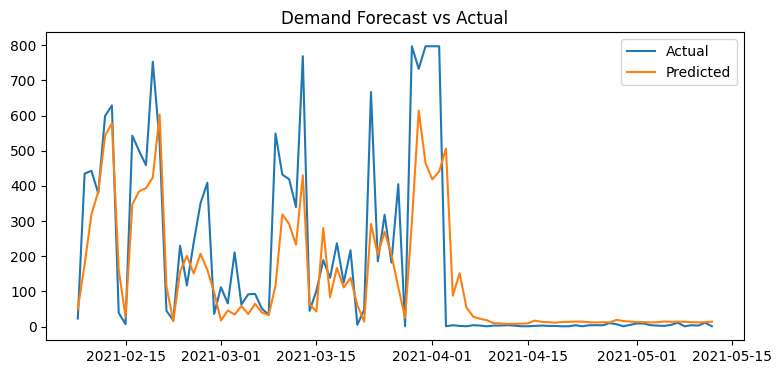

In [49]:

plt.figure(figsize=(9,4))
plt.plot(test['appointment_date_continuous'], y_test.values, label='Actual')
plt.plot(test['appointment_date_continuous'], pred, label='Predicted')
plt.title("Demand Forecast vs Actual")
plt.legend()
plt.show()


Model Behavior Analysis

Forecast captures regular weekly patterns

Extreme peaks likely driven by external events

Zero-demand window indicates clinic closure period

Additional features like holidays, lockdown flags, and specialty-wise demand would improve accuracy.

## 📊 Demand by Specialty

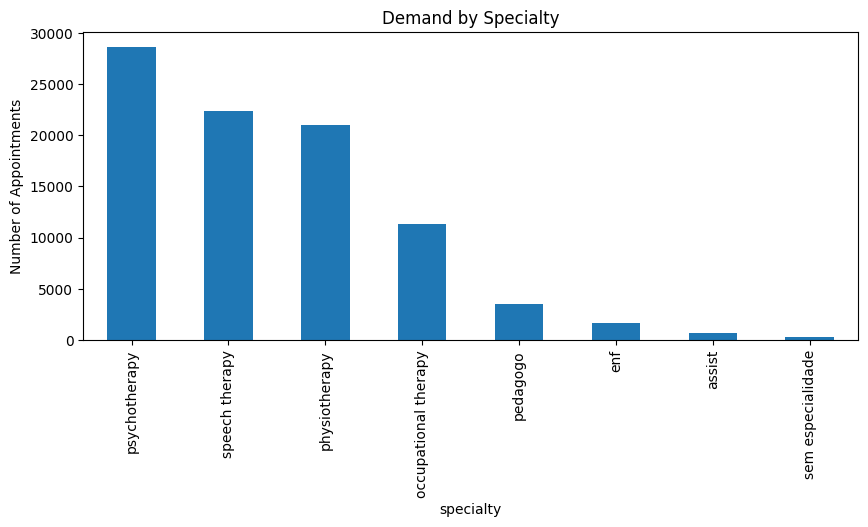

In [50]:
specialty_demand = df.groupby('specialty').size().sort_values(ascending=False)

plt.figure(figsize=(10,4))
specialty_demand.plot(kind='bar')
plt.title("Demand by Specialty")
plt.ylabel("Number of Appointments")
plt.show()

## Demand Variation by Month

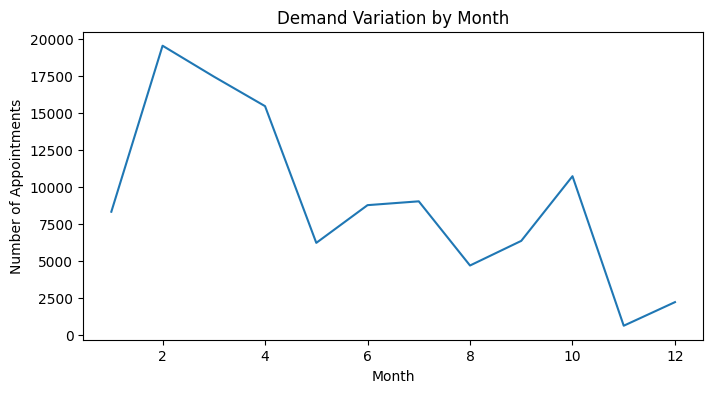

In [51]:
df['month'] = df['appointment_date_continuous'].dt.month

monthly_demand = df.groupby('month').size()

plt.figure(figsize=(8,4))
monthly_demand.plot()
plt.title("Demand Variation by Month")
plt.xlabel("Month")
plt.ylabel("Number of Appointments")
plt.show()

## Locations by Appointment Demand

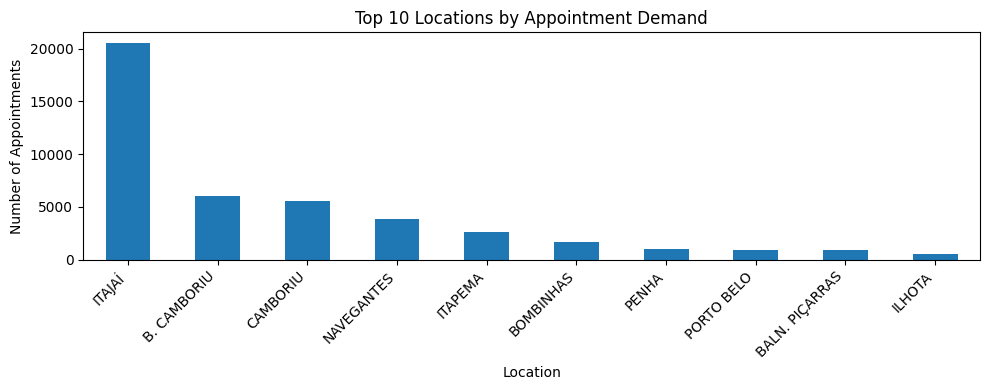

In [52]:
top_n = 10

place_demand = (
    df.groupby('place')
      .size()
      .sort_values(ascending=False)
      .head(top_n)
)

plt.figure(figsize=(10,4))
place_demand.plot(kind='bar')
plt.title(f"Top {top_n} Locations by Appointment Demand")
plt.xlabel("Location")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Demand vs Rain Intensity

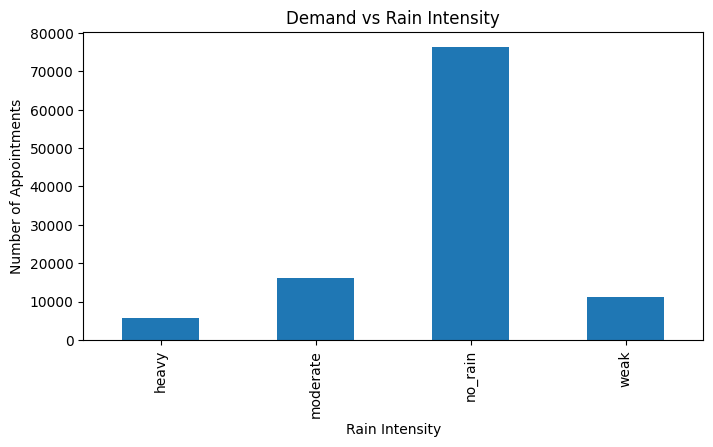

In [53]:
rain_demand = df.groupby('rain_intensity').size()

plt.figure(figsize=(8,4))
rain_demand.plot(kind='bar')
plt.title("Demand vs Rain Intensity")
plt.xlabel("Rain Intensity")
plt.ylabel("Number of Appointments")
plt.show()

## Elderly Ratio vs Demand

In [54]:
daily = df.groupby('appointment_date_continuous').agg(

    demand = ('specialty','count'),

    elderly_ratio = ('over_60_years_old','mean')
).reset_index()

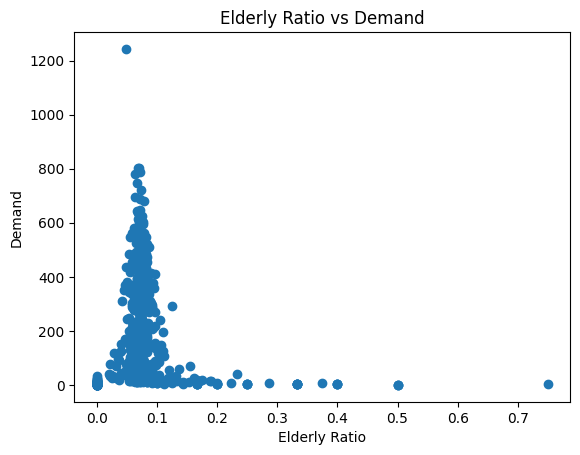

In [55]:
plt.scatter(daily['elderly_ratio'], daily['demand'])
plt.xlabel("Elderly Ratio")
plt.ylabel("Demand")
plt.title("Elderly Ratio vs Demand")
plt.show()

🔎 Key Observations
1️⃣ Most Days Have Low Elderly Ratio (0 – 0.12)

The dense vertical cluster around 0.05–0.10 shows:

Majority of days → elderly form only 5–10% of patients

Demand ranges from 50 to 700+

👉 Elderly are not the primary driver of total volume.

## Demand vs Heat Intensity

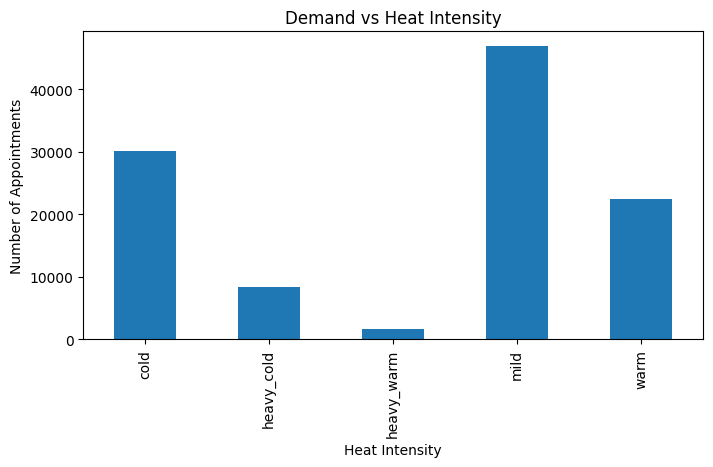

In [56]:
rain_demand = df.groupby('heat_intensity').size()

plt.figure(figsize=(8,4))
rain_demand.plot(kind='bar')
plt.title("Demand vs Heat Intensity")
plt.xlabel("Heat Intensity")
plt.ylabel("Number of Appointments")
plt.show()